In [1]:
import h5py
from lace.cosmo import cosmology
import numpy as np
import matplotlib.pyplot as plt
from cupix.likelihood.theory import Theory

# Me

In [2]:
with h5py.File('p3ds.hdf5', 'r') as f:
    k_los = f['k_los'][:]
    k = f['k'][:]
    plin = f['plin'][:]
    mu = f['mu'][:]
    p3d_lya_me = f['P3d_lya'][:]
    p3d_hcd_me = f['P3d_hcd'][:]
    p3d_hcdlya_me = f['P3d_hcdlya'][:]

# Cupix

In [3]:
cosmo = cosmology.Cosmology()
hubble = 0.71
cosmo.CAMBparams.set_cosmology(H0=hubble*100, ombh2=0.046*(hubble**2), omch2=0.27*(hubble**2))

class: <CAMBparams>
 WantCls = True
 WantTransfer = False
 WantScalars = True
 WantTensors = False
 WantVectors = False
 WantDerivedParameters = True
 Want_cl_2D_array = True
 Want_CMB = True
 Want_CMB_lensing = True
 DoLensing = True
 NonLinear = NonLinear_none
 Transfer: <TransferParams>
   high_precision = False
   accurate_massive_neutrinos = False
   kmax = 0.9
   k_per_logint = 0
   PK_num_redshifts = 1
   PK_redshifts = [0.0]
 want_zstar = False
 want_zdrag = False
 min_l = 2
 max_l = 2500
 max_l_tensor = 600
 max_eta_k = 5000.0
 max_eta_k_tensor = 1200.0
 ombh2 = 0.0231886
 omch2 = 0.136107
 omk = 0.0
 omnuh2 = 0.000644866570625114
 H0 = 71.0
 TCMB = 2.7255
 YHe = 0.24619933960101897
 num_nu_massless = 2.0293333333333337
 num_nu_massive = 1
 nu_mass_eigenstates = 1
 share_delta_neff = False
 nu_mass_degeneracies = [1.0146666666666666]
 nu_mass_fractions = [1.0]
 nu_mass_numbers = [1]
 InitPower: <InitialPowerLaw>
   tensor_parameterization = tensor_param_rpivot
   ns = 0.9665
 

In [4]:
# redshift and bias / beta from that paper
z = 2.5
bias = -0.18
beta = 1
# close to value used in McQuinn & White, although in there this is kpar smoothing only
kp_Mpc = 0.08 * cosmo.get_dkms_dMpc(z)
print('k_p = {:.3f} 1/Mpc'.format(kp_Mpc))
# HCD model (L_H
b_H = -0.036
beta_H = 0.5
L_H = 7.0  / cosmo.get_h()
print('L_H = {:.3f} Mpc'.format(L_H))
config = dict(bias=bias, beta=beta, q1=0, q2=0, kp_Mpc=kp_Mpc,
              include_hcd=True, b_H=b_H, beta_H=beta_H, L_H=L_H,
              verbose=False)

k_p = 6.136 1/Mpc
L_H = 9.859 Mpc


In [5]:
theory = Theory(z, fid_cosmo=cosmo, config=config)

In [6]:
linP = cosmo.get_linP_Mpc(z, k)

In [7]:
# Cupix
p3d_lya_cupix = []
nonlin = []
for mu_value in mu:
    p3d_lya_cupix.append(theory.get_p3d_lya_Mpc(k=k, mu=mu_value))
    lya_params = theory.lya_model.get_lya_params(cosmo, params={})
    nonlin.append(theory._compute_DNL_Arinyo(k, mu_value, linP, lya_params))
p3d_lya_cupix = np.array(p3d_lya_cupix)
nonlin = np.array(nonlin)

# Comparison

In [12]:
ratio = p3d_lya_cupix/p3d_lya_me

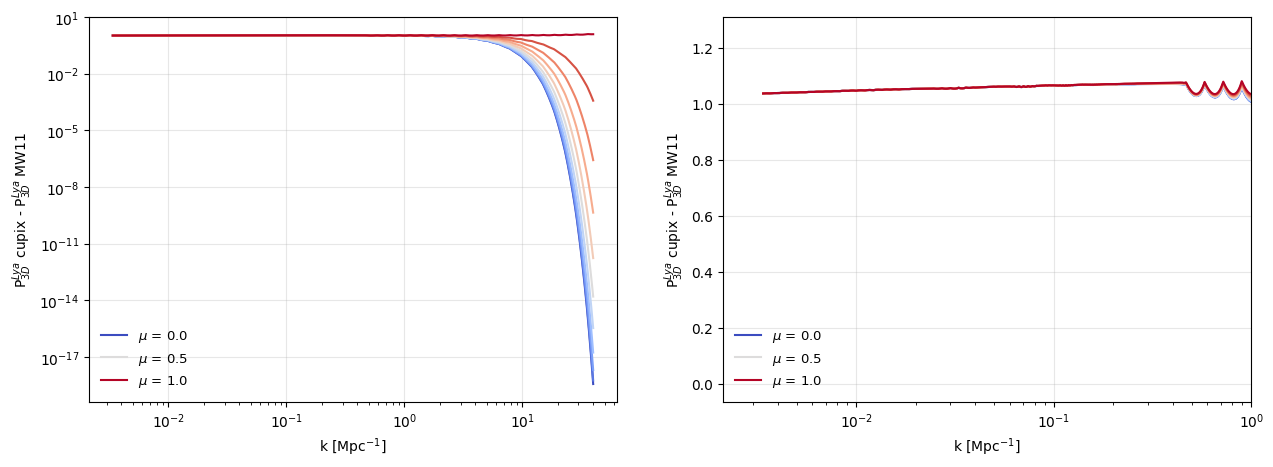

In [13]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
colors = plt.cm.coolwarm(np.linspace(0,1,len(mu)))     
plt.gca().set_prop_cycle('color', colors)
for i in np.arange(len(mu)):
    if i in [0, 5, 10]:
        plt.plot(k, ratio[i, :], label = '$\mu$ = %.1f' %mu[i])
    else:
        plt.plot(k, ratio[i, :])
plt.xscale('log')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{Lya}$ cupix - P$_{3D}^{Lya}$ MW11')

plt.subplot(1, 2, 2)
colors = plt.cm.coolwarm(np.linspace(0,1,len(mu)))     
plt.gca().set_prop_cycle('color', colors)
for i in np.arange(len(mu)):
    if i in [0, 5, 10]:
        plt.plot(k, ratio[i, :], label = '$\mu$ = %.1f' %mu[i])
    else:
        plt.plot(k, ratio[i, :])
plt.xscale('log')
plt.xlim(right=1e0)
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{Lya}$ cupix - P$_{3D}^{Lya}$ MW11');

In [14]:
ratio = p3d_lya_cupix/(p3d_lya_me/plin*linP)

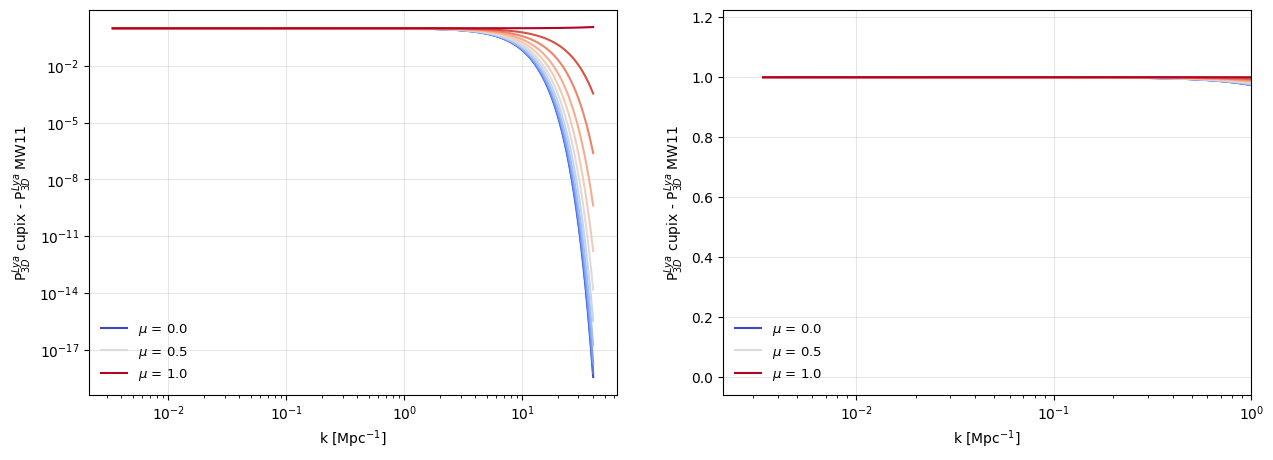

In [15]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
colors = plt.cm.coolwarm(np.linspace(0,1,len(mu)))     
plt.gca().set_prop_cycle('color', colors)
for i in np.arange(len(mu)):
    if i in [0, 5, 10]:
        plt.plot(k, ratio[i, :], label = '$\mu$ = %.1f' %mu[i])
    else:
        plt.plot(k, ratio[i, :])
plt.xscale('log')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{Lya}$ cupix - P$_{3D}^{Lya}$ MW11')

plt.subplot(1, 2, 2)
colors = plt.cm.coolwarm(np.linspace(0,1,len(mu)))     
plt.gca().set_prop_cycle('color', colors)
for i in np.arange(len(mu)):
    if i in [0, 5, 10]:
        plt.plot(k, ratio[i, :], label = '$\mu$ = %.1f' %mu[i])
    else:
        plt.plot(k, ratio[i, :])
plt.xscale('log')
plt.xlim(right=1e0)
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{Lya}$ cupix - P$_{3D}^{Lya}$ MW11');

### Cross

In [16]:
p3d_total_me = p3d_lya_me + p3d_hcd_me + p3d_hcdlya_me
ratio = p3d_total_cupix-p3d_total_me

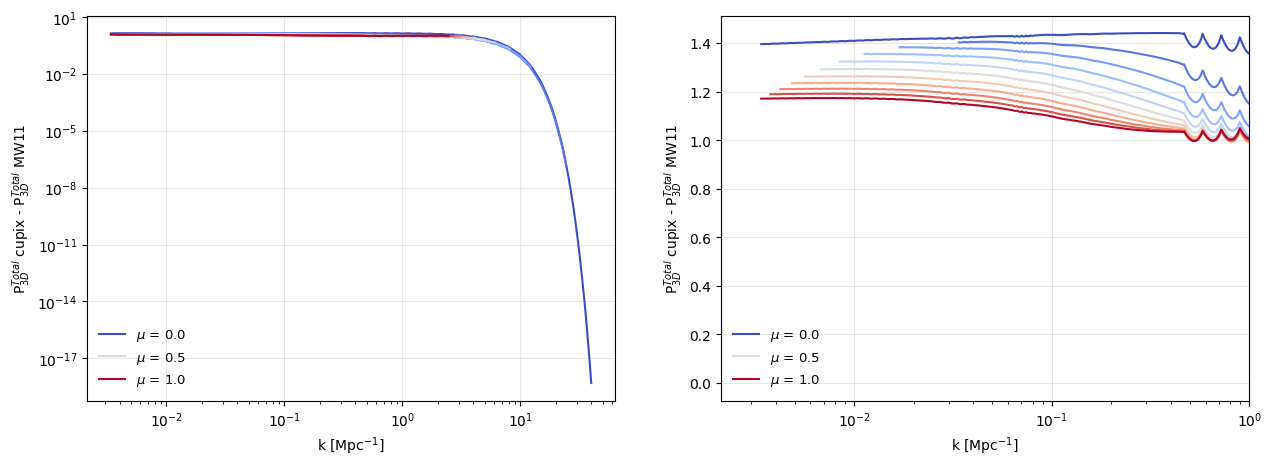

In [17]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
colors = plt.cm.coolwarm(np.linspace(0,1,len(mu)))     
plt.gca().set_prop_cycle('color', colors)
for i in np.arange(len(mu)):
    if i in [0, 5, 10]:
        plt.plot(k, ratio[i, :], label = '$\mu$ = %.1f' %mu[i])
    else:
        plt.plot(k, ratio[i, :])
plt.xscale('log')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{Total}$ cupix - P$_{3D}^{Total}$ MW11')

plt.subplot(1, 2, 2)
colors = plt.cm.coolwarm(np.linspace(0,1,len(mu)))     
plt.gca().set_prop_cycle('color', colors)
for i in np.arange(len(mu)):
    if i in [0, 5, 10]:
        plt.plot(k, ratio[i, :], label = '$\mu$ = %.1f' %mu[i])
    else:
        plt.plot(k, ratio[i, :])
plt.xscale('log')
plt.xlim(right=1e0)
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{Total}$ cupix - P$_{3D}^{Total}$ MW11');

In [18]:
ratio_me = p3d_total_me/p3d_lya_me -1
ratio_cupix= p3d_total_cupix/p3d_lya_cupix - 1

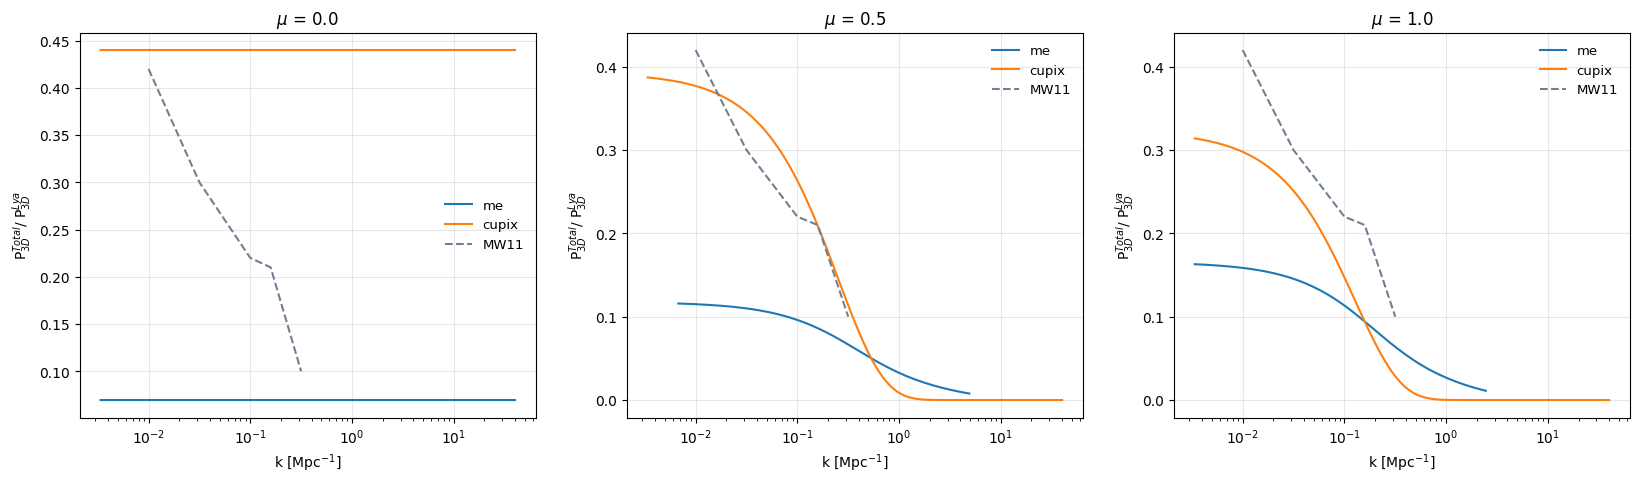

In [30]:
plt.figure(figsize=(20, 5))

plt.subplot(1, 3, 1)
i = 0
plt.plot(k, ratio_me[i, :], label = 'me')
plt.plot(k, ratio_cupix[i, :], label='cupix')
plt.plot(10**(np.array([-2, -1.5, -1, -0.8, -0.5])), [0.42, 0.3, 0.22, 0.21, 0.1], linestyle='--', color='slategrey', label='MW11')
plt.xscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{Total}$/ P$_{3D}^{Lya}$')
plt.title(r'$\mu$ = %.1f' %mu[i])

plt.subplot(1, 3, 2)
i = 5
plt.plot(k, ratio_me[i, :], label = 'me')
plt.plot(k, ratio_cupix[i, :], label='cupix')
plt.plot(10**(np.array([-2, -1.5, -1, -0.8, -0.5])), [0.42, 0.3, 0.22, 0.21, 0.1], linestyle='--', color='slategrey', label='MW11')
plt.xscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{Total}$/ P$_{3D}^{Lya}$')
plt.title(r'$\mu$ = %.1f' %mu[i])

plt.subplot(1, 3, 3)
i = 10
plt.plot(k, ratio_me[i, :], label = 'me')
plt.plot(k, ratio_cupix[i, :], label='cupix')
plt.plot(10**(np.array([-2, -1.5, -1, -0.8, -0.5])), [0.42, 0.3, 0.22, 0.21, 0.1], linestyle='--', color='slategrey', label='MW11')
plt.xscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{Total}$/ P$_{3D}^{Lya}$')
plt.title(r'$\mu$ = %.1f' %mu[i]);

In [31]:
hcdhcdlya_me = p3d_hcd_me + p3d_hcdlya_me
hcdhcdlya_cupix= p3d_total_cupix - p3d_lya_cupix

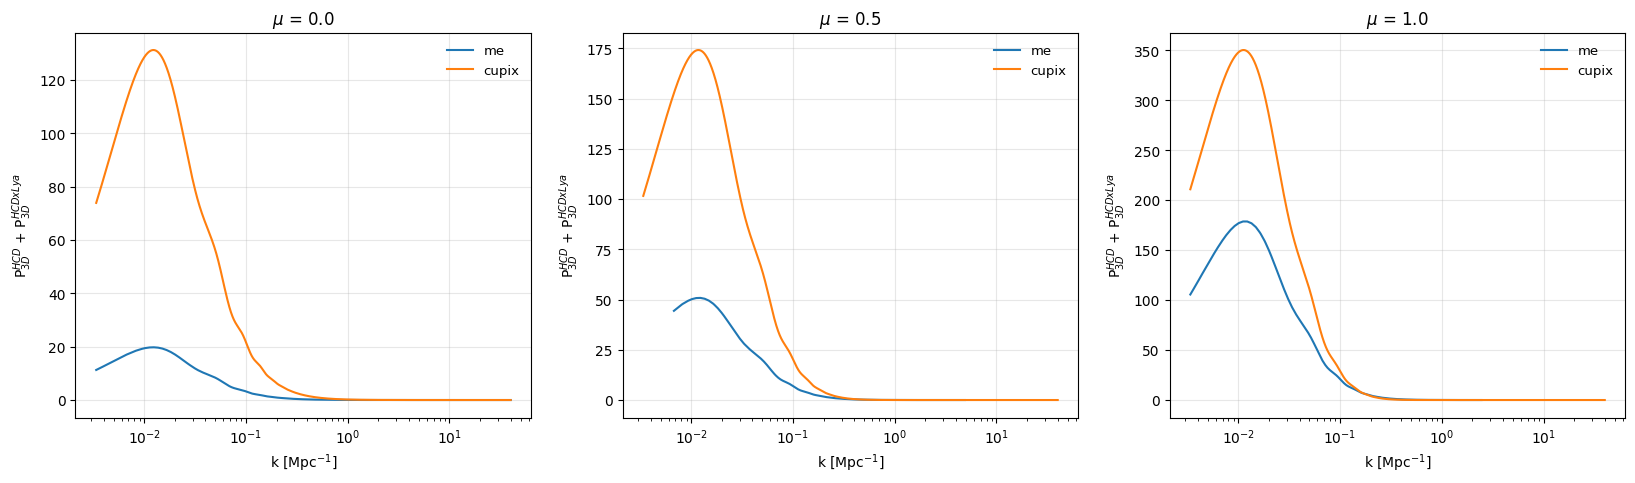

In [33]:
plt.figure(figsize=(20, 5))

plt.subplot(1, 3, 1)
i = 0
plt.plot(k, hcdhcdlya_me[i, :], label = 'me')
plt.plot(k, hcdhcdlya_cupix[i, :], label='cupix')
plt.xscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{HCD}$ + P$_{3D}^{HCDxLya}$')
plt.title(r'$\mu$ = %.1f' %mu[i])

plt.subplot(1, 3, 2)
i = 5
plt.plot(k, hcdhcdlya_me[i, :], label = 'me')
plt.plot(k, hcdhcdlya_cupix[i, :], label='cupix')
plt.xscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{HCD}$ + P$_{3D}^{HCDxLya}$')
plt.title(r'$\mu$ = %.1f' %mu[i])

plt.subplot(1, 3, 3)
i = 10
plt.plot(k, hcdhcdlya_me[i, :], label = 'me')
plt.plot(k, hcdhcdlya_cupix[i, :], label='cupix')
plt.xscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{HCD}$ + P$_{3D}^{HCDxLya}$')
plt.title(r'$\mu$ = %.1f' %mu[i]);